# Wellbeing and Macroeconomics: A SAGE Approach

## Overview

Standard macroeconomic models treat welfare as preference satisfaction: an agent is
as well off as the utility of the bundle they choose. This lecture takes a different
premise, namely that personal welfare depends on more than consumption, and that some
of its other determinants are shaped by economic choices in ways a standard model does
not record.

To make that idea operational we use the **SAGE framework** of
Lima de Miranda and Snower (2020), in which wellbeing has separate dimensions:

| | dimension | how it enters the model |
|---|---|---|
| **S** | Social cohesion | a public good `Q` that agents contribute time to |
| **A** | Agency | how much of a person's labour effort becomes income |
| **G** | material Gain | the standard consumption-leisure motive |
| **E** | Environment | not modelled here; it belongs to the research versions |

We build toward this in stages: start from models you already know, then add one
idea at a time.

1. The **neoclassical growth model**, the deterministic core of optimal saving.
2. The **real business cycle model**, which adds a productivity shock and a labour
   choice.
3. A **SAGE-RBC**, which gives the representative agent agency and social cohesion.
4. The **SAGE-Bewley model**, which replaces the representative agent with a
   distribution of households facing uninsurable risk, and asks what an activation
   policy does to the separate dimensions of their wellbeing, and to whom.

The first two rungs are deliberately brief, because the QuantEcon lectures cover
them in depth ([optimal growth](https://julia.quantecon.org/dynamic_programming/optgrowth.html),
[finite Markov chains](https://julia.quantecon.org/introduction_dynamics/finite_markov.html));
the destination is the fourth. The background assumed is dynamic programming at the
level of value function iteration, and enough Julia to read a loop. Every figure
below is produced by the code shown. We begin by loading the packages and the model
engine, fetching the engine from the repository if the file is not next to the
notebook, so the notebook runs anywhere.

In [1]:
using QuantEcon, Plots, Statistics, Printf, Downloads
isfile("sage_engine.jl") ||
    Downloads.download("https://raw.githubusercontent.com/conway1521/sage-bewley/main/sage_engine.jl",
                       "sage_engine.jl")
include("sage_engine.jl")
using .SAGEBewley
gr(fmt = :png, size = (820, 300))
C1, C2, C3, C4 = "#1f77b4", "#ff7f0e", "#2ca02c", "#9467bd"
BLUE, ORANGE = C1, C2;          # low income, high income (thesis colours)

## The Neoclassical Growth Model

A representative household maximises $\sum_{t} \beta^t \log c_t$ subject to the
resource constraint

$$
c_t + k_{t+1} = k_t^{\alpha} + (1-\delta) k_t .
$$

We solve it by value function iteration on a grid for capital, and keep the section
to a minimum: QuantEcon's
[optimal growth lecture](https://julia.quantecon.org/dynamic_programming/optgrowth.html)
develops the model and the method properly, and its only job here is to set the
pattern the next two models reuse. The Bewley model at the end switches to policy
iteration.

In [2]:
function solve_ncgm(; α=0.33, β=0.96, δ=0.10, nk=400, tol=1e-8, maxit=2000)
    kstar = (α / (1/β - 1 + δ))^(1/(1-α))
    kgrid = range(0.1*kstar, 1.6*kstar, length=nk)
    V = zeros(nk); Vnew = similar(V); g = zeros(Int, nk)
    for _ in 1:maxit
        for i in 1:nk
            resources = kgrid[i]^α + (1-δ)*kgrid[i]
            best = -Inf; bestj = 1
            for j in 1:nk
                c = resources - kgrid[j]
                c <= 0 && break
                val = log(c) + β*V[j]
                if val > best; best = val; bestj = j; end
            end
            Vnew[i] = best; g[i] = bestj
        end
        maximum(abs.(Vnew .- V)) < tol && (V .= Vnew; break)
        V .= Vnew
    end
    kgrid, kgrid[g], kstar, α, δ
end

kgrid, kpol, kstar, αn, δn = solve_ncgm();

Starting from a capital stock below the steady state, the economy saves and converges.
Capital and consumption both rise monotonically along the transition.

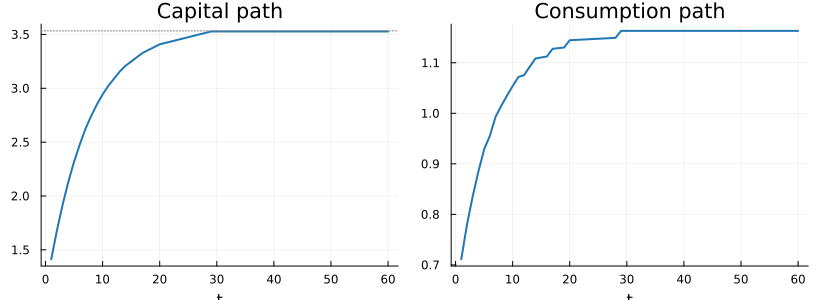

In [3]:
T = 60
kp = fill(0.4*kstar, T); cp = zeros(T)
for t in 1:T-1
    i = argmin(abs.(kgrid .- kp[t]))
    kp[t+1] = kpol[i]
    cp[t] = kp[t]^αn + (1-δn)*kp[t] - kp[t+1]
end
cp[T] = kp[T]^αn - δn*kp[T]
p1 = plot(1:T, kp, c=C1, lw=2, legend=false, title="Capital path", xlabel="t")
hline!(p1, [kstar], c=:gray, ls=:dot)
p2 = plot(1:T, cp, c=C1, lw=2, legend=false, title="Consumption path", xlabel="t")
plot(p1, p2, layout=(1,2))

## The Real Business Cycle Model

Now total factor productivity `z` follows a persistent AR(1) process, discretised
into a Markov chain with the Rouwenhorst method (Rouwenhorst 1995) (QuantEcon's
[finite Markov chains lecture](https://julia.quantecon.org/introduction_dynamics/finite_markov.html)
covers the toolkit), and the household chooses labour `n`. The state is `(k, z)` and
the calibration is the standard quarterly one. We fold the intratemporal labour
choice into the per-period reward, so value iteration stays a simple maximisation
over next-period capital, and after convergence we recover continuous policies
between grid points. That last step matters for what follows: the labour response to
a shock is a fraction of a percent, smaller than the steps a discrete policy takes on
any affordable grid, so without the recovery the labour figure would be showing the
grid, not the model. The same routine will serve the SAGE-RBC once we switch on
agency `αa` (the share of labour income retained) and a social-cohesion pull `Λ B`
away from work.

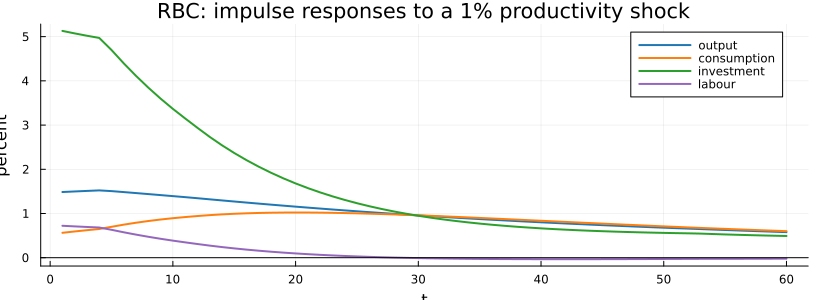

In [4]:
function solve_rbc(; α=1/3, β=0.984, δ=0.025, ψ=0.25, ρ=0.979, σ=0.0072,
                     αa=1.0, Λ=0.0, B=1.0, n_target=0.2, nk=180, tol=1e-6, maxit=1500)
    mc = rouwenhorst(7, ρ, σ); zv = exp.(mc.state_values); Π = mc.p
    rk_ss = 1/β + δ - 1
    k_ss  = (α/rk_ss)^(1/(1-α)) * n_target
    y_ss  = k_ss^α * n_target^(1-α)
    φ     = (1-α)*y_ss/n_target * (1/(y_ss - δ*k_ss)) * n_target^(-ψ)
    function best_n(k, z, kp)               # labour from the static first-order condition
        f(n) = begin
            y = z*k^α*n^(1-α)
            c = (αa*(1-α)+α)*y + (1-δ)*k - kp
            c <= 0 && return (-Inf, c)
            (c^(-1)*(αa*(1-α)+α)*(1-α)*y/n - φ*n^ψ - Λ*B, c)
        end
        lo, hi = 1e-4, 0.999
        for _ in 1:60
            mid = (lo+hi)/2
            f(mid)[1] > 0 ? (lo = mid) : (hi = mid)
        end
        n = (lo+hi)/2; n, f(n)[2]
    end
    kgrid = range(0.5*k_ss, 1.6*k_ss, length=nk)
    R = fill(-Inf, nk, 7, nk); N = zeros(nk, 7, nk)
    for iz in 1:7, ik in 1:nk, jk in 1:nk
        n, c = best_n(kgrid[ik], zv[iz], kgrid[jk])
        c <= 0 && continue
        R[ik,iz,jk] = log(c) - φ*n^(1+ψ)/(1+ψ) + Λ*B*(1-n); N[ik,iz,jk] = n
    end
    V = zeros(nk,7); Vnew = similar(V); gk = zeros(Int,nk,7)
    for _ in 1:maxit
        EV = V * Π'
        for iz in 1:7, ik in 1:nk
            best = -Inf; bj = 1
            for j in 1:nk
                val = R[ik,iz,j] + β*EV[j,iz]
                if val > best; best = val; bj = j; end
            end
            Vnew[ik,iz] = best; gk[ik,iz] = bj
        end
        maximum(abs.(Vnew .- V)) < tol && (V .= Vnew; break)
        V .= Vnew
    end
    # recover continuous policies: golden-section on k' between the discrete
    # optimum's neighbours, continuation value interpolated linearly. On the
    # grid alone the labour policy is a step function and the labour response
    # inherits the steps; this is the same recovery the Bewley engine uses.
    EV = V * Π'
    EVi(kp, iz) = begin
        j = clamp(searchsortedlast(kgrid, kp), 1, nk-1)
        t = (kp - kgrid[j]) / (kgrid[j+1] - kgrid[j])
        (1-t)*EV[j,iz] + t*EV[j+1,iz]
    end
    reward(k, z, kp) = begin
        n, c = best_n(k, z, kp)
        c <= 0 ? -Inf : log(c) - φ*n^(1+ψ)/(1+ψ) + Λ*B*(1-n)
    end
    kpol = zeros(nk,7); gn = zeros(nk,7); gold = (sqrt(5)-1)/2
    for iz in 1:7, ik in 1:nk
        j = gk[ik,iz]
        lo = kgrid[max(j-1,1)]; hi = kgrid[min(j+1,nk)]
        obj(kp) = reward(kgrid[ik], zv[iz], kp) + β*EVi(kp, iz)
        c = hi - gold*(hi-lo); d = lo + gold*(hi-lo); fc = obj(c); fd = obj(d)
        for _ in 1:40
            if fc > fd
                hi = d; d = c; fd = fc; c = hi - gold*(hi-lo); fc = obj(c)
            else
                lo = c; c = d; fc = fd; d = lo + gold*(hi-lo); fd = obj(d)
            end
        end
        kp = (lo+hi)/2
        kpol[ik,iz] = kp; gn[ik,iz] = best_n(kgrid[ik], zv[iz], kp)[1]
    end
    (; kgrid, zv, kpol, gn, α, δ, αa, ρ, k_ss)
end

function irf(m; shock=0.01, T=60)
    (; kgrid, zv, kpol, gn, α, δ, αa, ρ) = m
    nz = length(zv); nk = length(kgrid)
    function itp(P, k, z)
        ik = clamp(searchsortedlast(kgrid, k), 1, nk-1)
        tk = clamp((k-kgrid[ik])/(kgrid[ik+1]-kgrid[ik]), 0.0, 1.0)
        iz = clamp(searchsortedlast(zv, z), 1, nz-1)
        tz = clamp((z-zv[iz])/(zv[iz+1]-zv[iz]), 0.0, 1.0)
        (1-tk)*(1-tz)*P[ik,iz]+tk*(1-tz)*P[ik+1,iz]+(1-tk)*tz*P[ik,iz+1]+tk*tz*P[ik+1,iz+1]
    end
    kss = m.k_ss; for _ in 1:3000; kss = itp(kpol, kss, 1.0); end
    n_ss = itp(gn, kss, 1.0); y_ss = kss^α*n_ss^(1-α); i_ss = δ*kss
    c_ss = (αa*(1-α)+α)*y_ss - δ*kss
    zp = [exp(log(1+shock)*ρ^(t-1)) for t in 1:T]
    k=fill(kss,T+1); y=zeros(T); c=zeros(T); n=zeros(T); iv=zeros(T)
    for t in 1:T
        n[t] = itp(gn,k[t],zp[t]); k[t+1] = itp(kpol,k[t],zp[t])
        y[t]=zp[t]*k[t]^α*n[t]^(1-α); iv[t]=k[t+1]-(1-δ)*k[t]
        c[t]=(αa*(1-α)+α)*y[t]+(1-δ)*k[t]-k[t+1]
    end
    d(x,b)=100 .*(x ./ b .- 1)
    (; y=d(y,y_ss), c=d(c,c_ss), n=d(n,n_ss), iv=d(iv,i_ss), n_ss, c_ss, y_ss)
end

m_rbc = solve_rbc(); r_rbc = irf(m_rbc)
plot(title="RBC: impulse responses to a 1% productivity shock", xlabel="t", ylabel="percent")
plot!(1:length(r_rbc.y), r_rbc.y, lw=2, label="output", c=C1)
plot!(1:length(r_rbc.c), r_rbc.c, lw=2, label="consumption", c=C2)
plot!(1:length(r_rbc.iv), r_rbc.iv, lw=2, label="investment", c=C3)
plot!(1:length(r_rbc.n), r_rbc.n, lw=2, label="labour", c=C4)
hline!([0], c=:black, lw=1, label=false)

Output rises, consumption is smooth, labour rises, and investment is the most volatile
component. This is the textbook business cycle, the benchmark for what follows.

## A SAGE-RBC

Before the full heterogeneous-agent model, it helps to see what the SAGE ingredients
do even with a single representative agent. We give that agent **agency** `αa < 1`, so
only part of labour income is retained, and a **social-cohesion** reward `Λ B (1 - n)`
for time spent out of work. These are the same two ideas that drive the household
problem later. We solve the same model with the switches on and compare the responses.

steady-state hours: RBC 0.2000, SAGE-RBC 0.1906 (-4.7%)


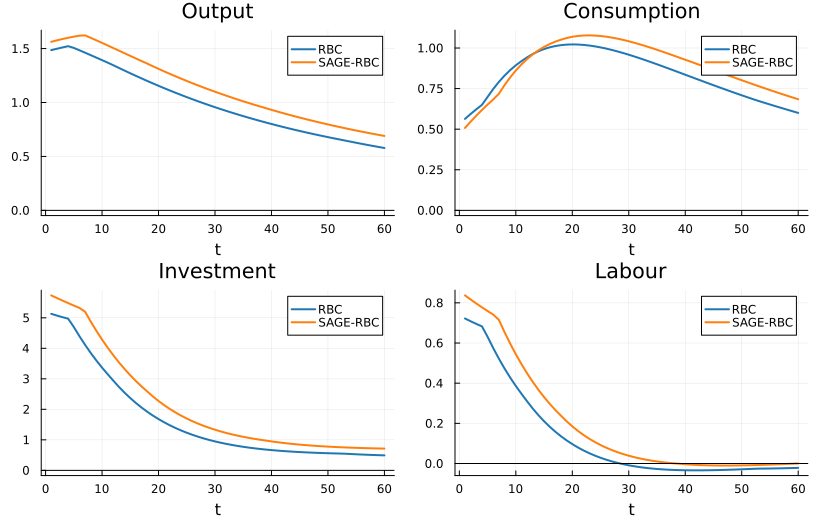

In [5]:
m_sage = solve_rbc(αa=0.85, Λ=0.30, B=0.85)
r_sage = irf(m_sage)
@printf("steady-state hours: RBC %.4f, SAGE-RBC %.4f (%+.1f%%)\n",
        r_rbc.n_ss, r_sage.n_ss, 100*(r_sage.n_ss/r_rbc.n_ss - 1))
function compare(field, title)
    a = getfield(r_rbc, field); b = getfield(r_sage, field)
    pl = plot(1:length(a), a, lw=2, label="RBC", c=C1, title=title, xlabel="t")
    plot!(pl, 1:length(b), b, lw=2, label="SAGE-RBC", c=C2)
    hline!(pl, [0], c=:black, lw=1, label=false); pl
end
plot(compare(:y,"Output"), compare(:c,"Consumption"),
     compare(:iv,"Investment"), compare(:n,"Labour"),
     layout=(2,2), size=(820,520))

The result is a near miss. The SAGE agent works about five percent fewer hours in
steady state, because the social pull makes time out of work valuable, and earns less
from each hour, because agency is below one. But the shape of its response to the
shock is almost the shape of the RBC's response. With a single representative agent,
agency and social cohesion move levels and leave the cycle nearly alone. Whatever
these forces do to an economy, they do it through who is affected and how
differently, and a representative agent has no one to be affected differently. So we
give the model a distribution of households.

## The SAGE Framework

In the SAGE framework an agent pursues several **decision objectives** at once, one
for each dimension of wellbeing, rather than maximising a single index. We keep two of
them. **Material gain** is the familiar consumption-leisure trade-off. **Social
cohesion** is the benefit from a public good that everyone contributes time to: an
agent who works effort `e` contributes `q = 1 - e` to society, and the public good is
the sum of those contributions.

**Agency**, denoted `α`, is the degree to which a person can turn effort into income.
It stands in for labour-market security, health, and skills, and it will differ across
households. Following the thesis behind this lecture (Conway 2020), agents
maximise utility as usual and the wellbeing dimensions are read off separately at the
optimum. The utility an agent maximises and the wellbeing we report are deliberately
different objects, and keeping them apart is what lets the model show material gain
and social cohesion moving in opposite directions.

## The SAGE-Bewley Model

We now place these ideas in a Bewley-Aiyagari economy
(Bewley 1986; Aiyagari 1994). Readers who know QuantEcon's
[Aiyagari lecture](https://julia.quantecon.org/multi_agent_models/aiyagari.html) will
recognise the bones of what follows; the differences are the labour-effort margin,
agency, and the public good. A unit mass of households faces uninsurable
idiosyncratic income risk, indexed by a productivity state `z` that is low or high
and follows a two-state Markov chain. Each period a household chooses consumption
`c`, next-period assets $a' \ge 0$, and labour effort $e \in [0,1]$, with $q = 1 - e$
the social contribution.

Utility is additively separable between material gain and the social term. The
separable form matters: it keeps the wealth effect on labour supply, and that wealth
effect is the model's engine, because households with more assets have a lower
marginal utility of consumption, work less, and contribute more time:

$$
u(c, e; z) \;=\;
\underbrace{\Gamma\left(\frac{c^{1-\gamma}}{1-\gamma} - \phi\,\frac{e^{1+\psi}}{1+\psi}\right)}_{\text{material gain } U^c}
\;+\; \underbrace{\Lambda\, B_z\, Q}_{\text{social cohesion } U^s},
$$

and the flow budget applies agency to labour income,

$$
c + a' \;=\; \alpha_z\, e\, z + R\, a, \qquad a' \ge 0 .
$$

The public good is the average contribution across the stationary distribution,
$Q = \mathbb{E}[\,1 - e\,]$.

The interest rate $R$ is taken as given, calibrated to a long-run real rate of about
two percent, rather than cleared by an asset market. This is an Aiyagari household
block in partial equilibrium: the equilibrium object we solve for is the social good
$Q$, through its fixed point, not the interest rate.

### The Income Process

Productivity $z$ follows a two-state Markov chain, the discretised primitive of the
idiosyncratic risk that everything downstream inherits. We show it first, because the
shape of the wealth distribution is a consequence of it.

In [6]:
p = SAGEParams()
zv, Π = income_process(p)
πstat = vec((Π^1000)[1, :])
@printf("productivity states  z = [%.3f, %.3f]\n", zv[1], zv[2])
@printf("transition matrix    Π = [%.2f  %.2f ;  %.2f  %.2f]\n", Π[1,1], Π[1,2], Π[2,1], Π[2,2])
@printf("stationary fractions   = [%.2f, %.2f]\n", πstat[1], πstat[2])

productivity states  z = [0.775, 1.225]
transition matrix    Π = [0.95  0.05 ;  0.05  0.95]
stationary fractions   = [0.50, 0.50]


Two states is a modelling choice, not a numerical economy. The states stand for the
lower- and higher-education groups of the underlying thesis, which is why agency
$\alpha_z$ and the belonging taste $B_z$ will differ across them, and why we speak of
groups rather than shocks when reading results. The engine discretises with the same
Rouwenhorst tool used for the RBC and solves finer chains unchanged; the education
pair is the configuration every result below uses.

Every default in `SAGEParams` is sourced. Risk aversion is 2, an elasticity of
intertemporal substitution of one half, the meta-analytic consensus of
Havranek (2015). The inverse Frisch is 2, a labour-supply elasticity of one
half, from the quasi-experimental consensus of Chetty, Guren, Manoli and Weber (2011). The discount
factor and interest rate are standard annual values. And the effort disutility is set
so the work share of committed time matches the French time-use figure of 0.53, where
paid work averages 3h24 a day against 3h01 of unpaid domestic and associative work
(INSEE 2010). Two facts the model was never aimed at then come out close to
data: about a third of households live hand to mouth (Kaplan, Violante and Weidner 2014), and the
wealth Gini is 0.55.

### Solving the Model

The solver lives in `sage_engine.jl`, and its structure is worth seeing, because it
is the Aiyagari algorithm with one twist at each end. Four steps.

**Step 1: fold effort into the reward.** For each state $(a, z)$ and each candidate
next-asset level $a'$, choose effort on a grid to maximise within-period utility.
After this inner choice the household problem has a single action, next assets,
exactly the shape of QuantEcon's Aiyagari lecture.

**Step 2: solve the discrete problem.** The result is a sparse state-action-pair
`DiscreteDP` (the QuantEcon.jl idiom), solved by policy iteration.

**Step 3: recover continuous policies.** Effort comes from the discrete joint
optimum. Next assets are then re-optimised continuously against the linearly
interpolated continuation value, golden-section between the discrete optimum's
neighbours. This is the same recovery step the RBC section used, for the same
reason: without it the policies inherit the steps of the grid and so does the wealth
distribution.

**Step 4: aggregate, and close the loop.** The stationary distribution uses the
lottery of Young (2010): each household's continuous savings choice is split
across the two bracketing grid nodes, the implied sparse transition matrix is
iterated to its fixed point, and the public good is read off as $Q = E[1-e]$. When
the social term is behavioural, so that $Q$ feeds back into the reward, an outer
damped fixed point on $Q$ wraps the whole solve.

Abridged from `sage_engine.jl`, the skeleton is:

```julia
# 1. effort folded into the reward: one action (next assets) remains
for i_z in 1:nz, i_a in 1:na, k in 1:na            # state (a, z), action a'
    best = -Inf
    for e in e_grid                                 # inner static effort choice
        c = R*a[i_a] + α[i_z]*e*z[i_z] - a[k]
        c <= 0 && continue
        best = max(best, u_c(c, e) + social(e, B[i_z], Q))
    end
    record_state_action_pair!(best)                 # sparse triplets
end

# 2. policy iteration on the sparse DiscreteDP (QuantEcon.jl)
ddp = DiscreteDP(Rvec, Qsparse, β, s_ind, a_ind)
σ   = solve(ddp, PFI).sigma

# 3. continuous savings against the interpolated continuation value
a′ = golden_max(ap -> u_c(resources - ap, e⋆) + β * EV_interp(ap, z), lo, hi)

# 4. Young (2010) lottery -> stationary λ -> Q = E[1-e];
#    outer damped loop on Q when the social term is behavioural
```

With the solver in hand, we solve the default calibration and read off the decision
rules.

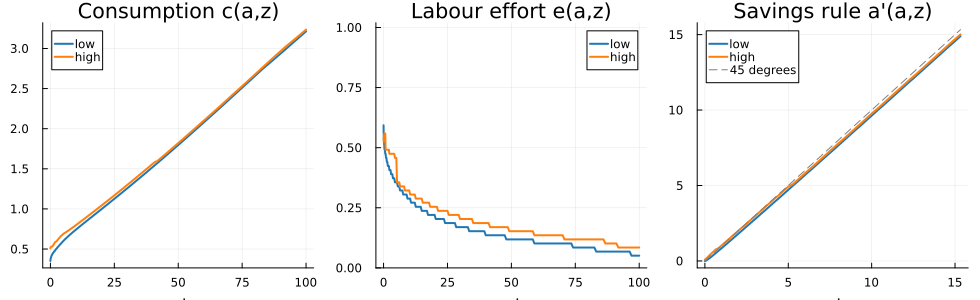

In [7]:
sol = solve_model(p)
a = sol.a_grid
ix = findfirst(>(15.0), a); ix = ix === nothing ? length(a) : ix
p1 = plot(a, sol.c[:,1], c=BLUE, lw=2, label="low", title="Consumption c(a,z)", xlabel="assets a")
plot!(p1, a, sol.c[:,2], c=ORANGE, lw=2, label="high")
p2 = plot(a, sol.e[:,1], c=BLUE, lw=2, label="low", title="Labour effort e(a,z)",
          xlabel="assets a", ylims=(0,1.02))
plot!(p2, a, sol.e[:,2], c=ORANGE, lw=2, label="high")
p3 = plot(a[1:ix], sol.a_next[1:ix,1], c=BLUE, lw=2, label="low",
          title="Savings rule a'(a,z)", xlabel="assets a")
plot!(p3, a[1:ix], sol.a_next[1:ix,2], c=ORANGE, lw=2, label="high")
plot!(p3, a[1:ix], a[1:ix], c=:gray, ls=:dash, label="45 degrees")
plot(p1, p2, p3, layout=(1,3), size=(980,300))

All three rules behave the way a Bewley model should. Consumption rises with
assets. The savings rule $a'(a,z)$ starts at the borrowing constraint and rises, hugging
the 45-degree line from just below: the near-unit $\beta R$ gives a high target, so
households accumulate slowly and the gap from 45 degrees is what produces the long right
tail of the distribution. At the low end the low-income state sits against the constraint
$a' = 0$, which is the hand-to-mouth mass. That the stationary distribution puts zero
weight on the top grid point, reported below, confirms the grid is wide enough that this
tail is resolved rather than truncated. The effort policy carries the model's
central intuition: effort falls with wealth, because wealthier households have a lower
marginal utility of consumption and turn their time toward social contribution. Under
the evidence-based curvature this wealth effect is strong enough that the higher-agency
group, being richer on average, works somewhat less and contributes somewhat more time
overall, the pattern participation data actually show.

The wealth distribution itself has the usual Bewley shape, a large mass of low-income
households at the borrowing constraint trailing into a thin right tail. The Lorenz
curve summarises the inequality it implies, and the bar shows which income group ends
up supplying the social good.

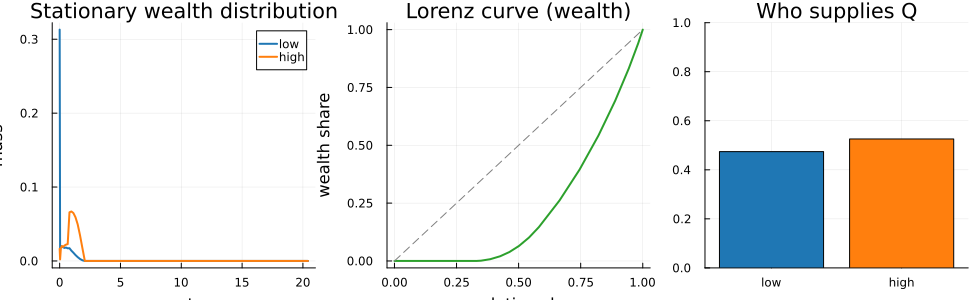

In [8]:
function lorenz(vals, w)
    o = sortperm(vals); cw = cumsum(w[o]); cv = cumsum(vals[o] .* w[o])
    vcat(0.0, cw ./ cw[end]), vcat(0.0, cv ./ cv[end])
end
imax = something(findfirst(>(20.0), a), length(a))
pa = plot(a[1:imax], sol.λ[1:imax,1], c=BLUE, lw=2, label="low",
          title="Stationary wealth distribution", xlabel="assets a", ylabel="mass")
plot!(pa, a[1:imax], sol.λ[1:imax,2], c=ORANGE, lw=2, label="high")
lx, ly = lorenz(vec(repeat(a, 1, p.nz)), vec(sol.λ))
pl = plot(lx, ly, c=C3, lw=2, legend=false, title="Lorenz curve (wealth)",
          xlabel="population share", ylabel="wealth share")
plot!(pl, [0,1], [0,1], c=:gray, ls=:dash)
sh = public_good_shares(sol)
pb = bar(["low","high"], sh, c=[BLUE,ORANGE], legend=false,
         title="Who supplies Q", ylims=(0,1))
plot(pa, pl, pb, layout=(1,3), size=(980,300))

In [9]:
@printf("Gini (wealth)          = %.3f\n", wealth_gini(sol))
@printf("Share at constraint    = %.1f%%\n", 100*frac_constrained(sol))
@printf("Public good size Q     = %.3f, supplied %.0f%% by low income\n",
        sol.Q, 100*public_good_shares(sol)[1])
@printf("Mass at top grid point = %.1e  (a numerical check: ~0 means the asset\n",
        sum(sol.λ[end, :]))
@printf("                          grid is wide enough not to truncate the tail)\n")

Gini (wealth)          = 0.548
Share at constraint    = 32.9%
Public good size Q     = 0.467, supplied 47% by low income
Mass at top grid point = 0.0e+00  (a numerical check: ~0 means the asset
                          grid is wide enough not to truncate the tail)


Under the sourced calibration the higher-income group supplies slightly more of the
public good, about 53 percent, because the wealth effect dominates: better-rewarded
households are richer, and richer households can afford to give time. This matches
the well-documented fact that volunteering and associative participation rise with
income and education. The model's distributional tension is then a double
disadvantage: the lower-income group both supplies less of the social fabric and,
with $B_{low} < B_{high}$, enjoys what exists less per unit.

### The Wellbeing Dashboard

We now read off the two decision objectives at the optimum and display them as a
**balanced dashboard**, by wealth quartile within each income group. Material gain
$U^c$ rises with wealth. Social cohesion $U^s = \Lambda B Q$ is flat within a group and
higher for high-income households, who enjoy the public good more even though they
supply less of it. One detail to expect in the figure: the bottom two quartiles of
the lower group print the same bar, because the poorest half of that group sits at
the borrowing constraint, so its quartiles coincide.

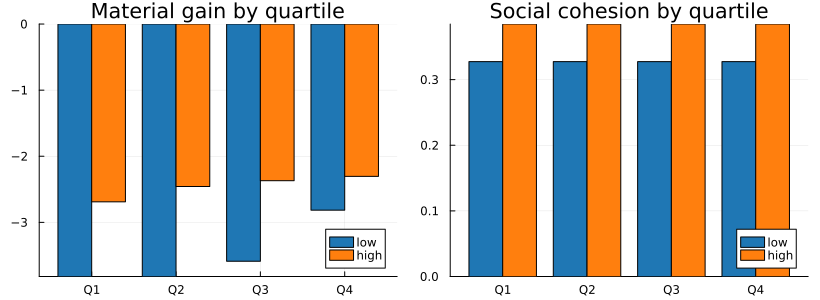

In [10]:
function dashboard(sol)
    # exact quartile means: each grid point's mass occupies an interval of the
    # within-group CDF, and a quartile receives the part that overlaps it, so
    # the atom at the borrowing constraint is split across quartiles correctly
    Uc = zeros(4,2); Us = zeros(4,2)
    for z in 1:2
        w = sol.λ[:,z] ./ sum(sol.λ[:,z]); cw = cumsum(w)
        lo = vcat(0.0, cw[1:end-1])
        for qi in 1:4
            qa, qb = (qi-1)/4, qi/4
            ov = max.(min.(cw, qb) .- max.(lo, qa), 0.0)
            ww = ov ./ sum(ov)
            Uc[qi,z] = sum(ww .* sol.Uc[:,z]); Us[qi,z] = sum(ww .* sol.Us[:,z])
        end
    end
    Uc, Us
end
function gbar(cols; title)
    m = 4; w = 0.4; pl = plot()
    bar!(pl, (1:m).-w/2, cols[:,1], bar_width=w, label="low",  color=BLUE)
    bar!(pl, (1:m).+w/2, cols[:,2], bar_width=w, label="high", color=ORANGE)
    plot!(pl, xticks=(1:m, ["Q1","Q2","Q3","Q4"]), title=title); pl
end
Uc, Us = dashboard(sol)
plot(gbar(Uc; title="Material gain by quartile"),
     gbar(Us; title="Social cohesion by quartile"), layout=(1,2))

### A Policy Experiment and the Decoupling

A government wants people in work, so it subsidises work: a make-work-pay subsidy of
20 percent on labour income, financed by a lump-sum tax so that the budget balances.
We run it under behavioural social cohesion (the warm-glow form, in which the act of
contributing enters utility, so effort responds). Real governments run exactly this
policy. In the model it produces a **decoupling**: the subsidy raises the return to
work, households work more and contribute less, so consumption rises while the public
good falls.

In [11]:
function solve_financed(p; subsidy = 0.0, tol = 1e-5, maxit = 40)
    z_vals, _ = SAGEBewley.income_process(p)
    T = 0.0
    sol = solve_model(update(p; subsidy = subsidy, lumptax = T))
    for _ in 1:maxit
        paid = sum(sol.λ[ia, iz] * subsidy * p.α[iz] * sol.e[ia, iz] * z_vals[iz]
                   for iz in 1:p.nz, ia in 1:p.na)
        abs(paid - T) < tol && break
        T = 0.5 * T + 0.5 * paid
        sol = solve_model(update(p; subsidy = subsidy, lumptax = T))
    end
    sol
end
pw   = update(p; social_mode = :warmglow, social_strength = 1.0)
s0   = solve_financed(pw; subsidy = 0.0)
s1   = solve_financed(pw; subsidy = 0.20)
agg(s, M) = sum(s.λ .* M)
@printf("consumption: %.3f to %.3f (%+.1f%%)\n",
        agg(s0, s0.c), agg(s1, s1.c), 100*(agg(s1,s1.c)/agg(s0,s0.c)-1))
@printf("public good: %.3f to %.3f (%+.1f%%)\n", s0.Q, s1.Q, 100*(s1.Q/s0.Q-1))

consumption: 0.438 to 0.462 (+5.5%)
public good: 0.491 to 0.468 (-4.7%)


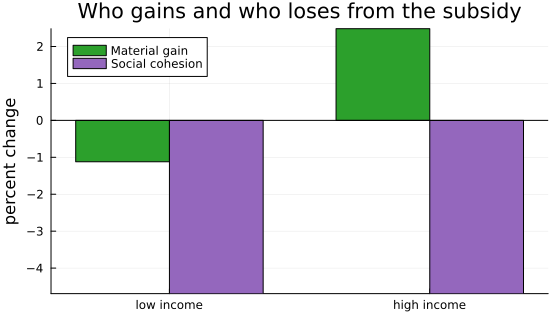

In [12]:
avg(s, M, z) = sum((s.λ[:,z]./sum(s.λ[:,z])) .* M[:,z])
dUc = [100*(avg(s1,s1.Uc,z) - avg(s0,s0.Uc,z))/abs(avg(s0,s0.Uc,z)) for z in 1:2]
dUs = [100*(pw.Λ*pw.B[z]*s1.Q - pw.Λ*pw.B[z]*s0.Q)/abs(pw.Λ*pw.B[z]*s0.Q) for z in 1:2]
pl = plot()
bar!(pl, [1,2].-0.18, dUc, bar_width=0.36, label="Material gain", color=C3)
bar!(pl, [1,2].+0.18, dUs, bar_width=0.36, label="Social cohesion", color=C4)
plot!(pl, xticks=([1,2],["low income","high income"]), ylabel="percent change", size=(560,320),
      title="Who gains and who loses from the subsidy")
hline!(pl, [0], c=:black, lw=1, label=false); pl

Aggregate consumption rises. But the lump-sum financing is the same for everyone
while the subsidy is proportional to labour income, so the lower-income group's
material gain falls outright while the higher-income group's rises, and both groups
lose part of the social dimension as the public good shrinks. The lower-income group
loses on every dimension at once. A planner reading a single consumption index sees
the aggregate gain and adopts the policy. A planner reading the dashboard sees the
social cost and who bears it. The model makes no claim that the policy is wrong; the
claim is about measurement, because a single index cannot see what the policy trades
away or from whom.

### Country Calibrations

The defaults above are the French calibration. The engine carries seven country rows
calibrated to one standardised pipeline: OECD How's Life for the agency and belonging
gradients, the World Inequality Database for the wealth Gini, Kaplan, Violante and Weidner (2014)
for the hand-to-mouth share, the Multinational Time Use Study for the work share, and
the World Values Survey for the participation gradient, with the full sourcing
documented in the research repository.

In [13]:
println("countries available: ", join(sort(collect(keys(COUNTRIES))), ", "))

countries available: CN, CO, DE, FR, IT, US, ZA


To switch the model to a country, call `country_params(code)`. Below, we solve every
country and report the calibrated and untargeted moments side by side.

In [14]:
function row(code)
    p = country_params(code)
    s = solve_model(p)
    tg = country_targets(code)
    (code = code, Q = s.Q, wg = wealth_gini(s), htm = frac_constrained(s), tg = tg)
end
results = [row(c) for c in ("FR","DE","IT","US","CO","ZA","CN")]
@printf("%-3s | %-12s | %-12s | %-12s | %-12s\n",
        "cty","work share","wealth Gini","HtM share","Q (fabric)")
for rw in results
    @printf("%-3s |  %.2f / %.2f |  %.2f / %.2f |  %.2f / %.2f |  %.3f\n",
            rw.code, 1 - rw.Q, rw.tg.work_share,
            rw.wg, rw.tg.wealth_gini, rw.htm, rw.tg.htm, rw.Q)
end

cty | work share   | wealth Gini  | HtM share    | Q (fabric)  
FR  |  0.52 / 0.53 |  0.55 / 0.68 |  0.33 / 0.30 |  0.475
DE  |  0.55 / 0.55 |  0.54 / 0.78 |  0.33 / 0.32 |  0.450
IT  |  0.55 / 0.55 |  0.52 / 0.61 |  0.29 / 0.41 |  0.450
US  |  0.60 / 0.60 |  0.51 / 0.85 |  0.27 / 0.31 |  0.400
CO  |  0.60 / 0.60 |  0.41 / 0.81 |  0.11 / 0.55 |  0.400
ZA  |  0.55 / 0.55 |  0.37 / 0.95 |  0.08 / 0.60 |  0.450
CN  |  0.64 / 0.65 |  0.42 / 0.74 |  0.12 / 0.50 |  0.358


The work share hits its target country by country, by construction. The hand-to-mouth
share is in the right neighbourhood for the OECD members and undershoots for the
developing countries, where the one-asset Bewley structure cannot simultaneously
deliver a very high hand-to-mouth share and a very high wealth Gini. The wealth Gini
itself is a known limitation of one-asset models: standard calibrations of this class
reach 0.38 or so; this one reaches 0.55 for the European calibrations, which is
closer to data without yet matching the very high Ginis of the United States or South
Africa. Closing that gap is a two-asset extension along Kaplan, Violante and Weidner (2014).

In [15]:
# a country-switch demo: re-run the policy experiment with the German calibration
de   = update(country_params("DE"); social_mode = :warmglow, social_strength = 1.0)
s0de = solve_financed(de; subsidy = 0.0)
s1de = solve_financed(de; subsidy = 0.20)
@printf("Germany under the financed 20%% subsidy:\n")
@printf("  consumption %+.1f%%   public good %+.1f%%\n",
        100*(agg(s1de, s1de.c)/agg(s0de, s0de.c) - 1),
        100*(s1de.Q/s0de.Q - 1))

Germany under the financed 20% subsidy:
  consumption +5.9%   public good -5.6%


Switch the country by changing `"DE"`. Every country row is one call to
`country_params(code)`.

## Exercises

Everything needed for these is already loaded. Try each one before opening the
solution.

**Exercise 1.** The SAGE-RBC switched on two things at once, agency and the social pull. Separate
them: solve the model with agency alone (`αa = 0.85`) and with the social pull alone
(`Λ = 0.30, B = 0.85`). Which switch moves the level of steady-state hours, and
which moves the response of hours to the shock?


**Solution.**

steady-state hours:  RBC 0.2000 | agency only 0.2001 | social only 0.1907 | both 0.1906


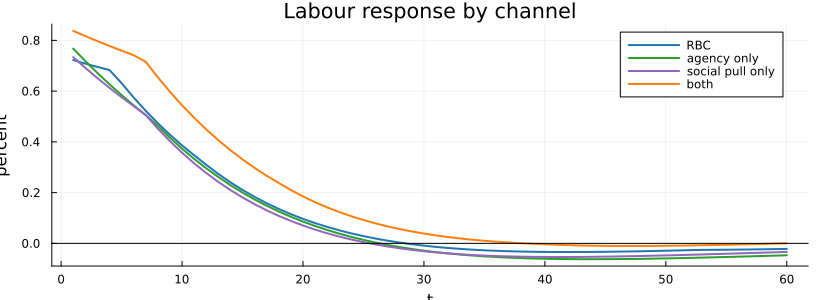

In [16]:
r_agency = irf(solve_rbc(αa = 0.85))
r_social = irf(solve_rbc(Λ = 0.30, B = 0.85))
@printf("steady-state hours:  RBC %.4f | agency only %.4f | social only %.4f | both %.4f\n",
        r_rbc.n_ss, r_agency.n_ss, r_social.n_ss, r_sage.n_ss)
pl = plot(title = "Labour response by channel", xlabel = "t", ylabel = "percent")
plot!(pl, r_rbc.n, lw = 2, label = "RBC", c = C1)
plot!(pl, r_agency.n, lw = 2, label = "agency only", c = C3)
plot!(pl, r_social.n, lw = 2, label = "social pull only", c = C4)
plot!(pl, r_sage.n, lw = 2, label = "both", c = C2)
hline!(pl, [0], c = :black, lw = 1, label = false); pl

The level and the cycle separate cleanly. The social pull cuts steady-state hours by
almost five percent, because it prices time out of work. Agency alone barely moves
them: under log utility the income and substitution effects of a lower return nearly
cancel, a classic result. And all four responses to the shock are similar, which
repeats the section's message from a different angle: with a representative agent
these forces live in the levels, and it takes heterogeneity to make them bite.


**Exercise 2.** The Bewley calibration sets the discount factor and the interest rate jointly, with
$\beta R$ well inside one. Re-solve the baseline with `R = 1.03` and compare the
share of households at the constraint and the wealth Gini. What should happen as
$\beta R$ approaches one?


**Solution.**

In [17]:
solR = solve_model(update(p; R = 1.03))
@printf("R = 1.02: Gini %.3f, at constraint %.1f%%\n",
        wealth_gini(sol), 100*frac_constrained(sol))
@printf("R = 1.03: Gini %.3f, at constraint %.1f%%\n",
        wealth_gini(solR), 100*frac_constrained(solR))
@printf("mass at top grid point: %.1e\n", sum(solR.λ[end, :]))

R = 1.02: Gini 0.548, at constraint 32.9%
R = 1.03: Gini 0.513, at constraint 24.2%
mass at top grid point: 0.0e+00


A higher return strengthens the saving motive, so fewer households sit at the
constraint and more wealth accumulates. In the limit $\beta R \to 1$ the target asset
level diverges and the stationary distribution starts piling mass on whatever ceiling
the grid imposes, which is why the top-grid check exists and why the calibration keeps
the product safely inside one.


**Exercise 3.** Run the financed 20 percent subsidy for the United States row and compare the
decoupling with France. The rows differ in the agency gap, the belonging tastes, and
the cohesion weight. Which effects change size?


**Solution.**

In [18]:
for code in ("FR", "US")
    pc = update(country_params(code); social_mode = :warmglow, social_strength = 1.0)
    b0 = solve_financed(pc; subsidy = 0.0)
    b1 = solve_financed(pc; subsidy = 0.20)
    @printf("%s: consumption %+.1f%%, public good %+.1f%%\n", code,
            100*(agg(b1, b1.c)/agg(b0, b0.c) - 1), 100*(b1.Q/b0.Q - 1))
end

FR: consumption +6.5%, public good -5.8%
US: consumption +6.7%, public good -7.5%


The signs are the portable result: every calibration decouples the same way. The
sizes move with the row, and tracing a size difference back to a parameter difference
is a useful way to learn what each dial does.


## Final Remarks

This lecture compares stationary economies rather than full transitions, uses the
simplest behavioural form of the social term, and holds the interest rate fixed.
Natural extensions run in three directions: a discrete participation margin in the
tradition of discrete choice with social interactions, where activation policy is
amplified by the social feedback; a homophily channel in which belonging is drawn
from one's own group, which segregates cohesion across education groups; and the
general-equilibrium close in which $R$ clears the capital market.

On provenance: the model is from my master's thesis (Conway 2020), which
operationalised the SAGE framework of Lima de Miranda and Snower (2020) in a
heterogeneous-agent economy. This page and its vendored solver live at
[github.com/conway1521/sage-bewley](https://github.com/conway1521/sage-bewley); the
maintained engine, the calibration data and its sourcing, and an interactive Pluto
notebook live in the research repository,
[github.com/conway1521/sage_macro](https://github.com/conway1521/sage_macro).

## References

Aiyagari, S. Rao (1994). Uninsured idiosyncratic risk and aggregate saving. *Quarterly Journal of Economics* 109(3), 659-684.

Bewley, Truman (1986). Stationary monetary equilibrium with a continuum of independently fluctuating consumers. In *Contributions to Mathematical Economics in Honor of Gerard Debreu*, North-Holland.

Chetty, Raj, Adam Guren, Day Manoli and Andrea Weber (2011). Are micro and macro labor supply elasticities consistent? *American Economic Review* 101(3), 471-475.

Conway, Alessandro (2020). Wellbeing and macroeconomics: a SAGE approach. Master's thesis, Sciences Po Paris.

Havranek, Tomas (2015). Measuring intertemporal substitution: the importance of method choices and selective reporting. *Journal of the European Economic Association* 13(6), 1180-1204.

INSEE (2010). Enquete Emploi du temps 2009-2010.

Kaplan, Greg, Giovanni L. Violante and Justin Weidner (2014). The wealthy hand-to-mouth. *Brookings Papers on Economic Activity*, Spring, 77-138.

Lima de Miranda, Katharina and Dennis J. Snower (2020). Recoupling economic and social prosperity. *Global Perspectives* 1(1).

Rouwenhorst, K. Geert (1995). Asset pricing implications of equilibrium business cycle models. In *Frontiers of Business Cycle Research*, Princeton University Press.

Young, Eric R. (2010). Solving the incomplete markets model with aggregate uncertainty using the Krusell-Smith algorithm and non-stochastic simulations. *Journal of Economic Dynamics and Control* 34(1), 36-41.